##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [ ]:
# Import Libraries


# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)


# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)


# Load the images


# Predict classes


In [4]:
# Import Libraries
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

import tensorflow as tf
import keras
import keras_hub

In [5]:
# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

100%|██████████| 1.65k/1.65k [00:00<00:00, 3.74MB/s]


In [6]:
# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    load_weights=True
)

# Load ImageNet class names
classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(classes_url)
response.raise_for_status()
class_names = response.text.strip().split("\n")

print("Number of ImageNet classes:", len(class_names))


Number of ImageNet classes: 1000


In [9]:
# Load the images


image_data = [
    {
        "name": "golden_retriever.jpg",
        "url": "https://images.unsplash.com/photo-1552053831-71594a27632d",
        "true_label": "golden retriever"
    },
    {
        "name": "sports_car.jpg",
        "url": "https://images.unsplash.com/photo-1503376780353-7e6692767b70",
        "true_label": "sports car"
    },
    {
        "name": "espresso.jpg",
        "url": "https://images.unsplash.com/photo-1511920170033-f8396924c348",
        "true_label": "espresso"
    },
    {
        "name": "computer_mouse.jpg",
        "url": "https://images.unsplash.com/photo-1587829741301-dc798b83add3",
        "true_label": "mouse"
    },
    {
        "name": "dough.jpg",
        "url": "https://images.unsplash.com/photo-1604908176997-4315c5c3b9d7",
        "true_label": "dough"
    }
]

os.makedirs("test_images", exist_ok=True)

image_paths = []

headers = {"User-Agent": "Mozilla/5.0"}

for item in image_data:
    response = requests.get(item["url"], headers=headers)

    if "image" not in response.headers.get("Content-Type", ""):
        print(f"Skipping {item['name']} - not an image")
        continue

    img = Image.open(BytesIO(response.content)).convert("RGB")

    save_path = os.path.join("test_images", item["name"])
    img.save(save_path)

    image_paths.append(save_path)

print("Images downloaded successfully:")
print(image_paths)

Skipping dough.jpg - not an image
Images downloaded successfully:
['test_images/golden_retriever.jpg', 'test_images/sports_car.jpg', 'test_images/espresso.jpg', 'test_images/computer_mouse.jpg']


In [15]:
# Predict classes
results = []

for item, path in zip(image_data, image_paths):
    img = Image.open(path).convert("RGB")

    x = np.array(img, dtype=np.uint8)
    x = np.expand_dims(x, axis=0)

    # Required preprocessing using KerasHub preprocessor
    x_processed = preprocessor(x)

    # Predict using pretrained ViT
    logits = model(x_processed, training=False).numpy()
    pred_id = int(np.argmax(logits, axis=-1)[0])
    pred_label = class_names[pred_id]
    true_label = item["true_label"].lower()
    pred_label_lower = pred_label.lower()



    is_correct = (
    true_label in pred_label_lower or
    pred_label_lower in true_label
)

    results.append({
        "Image File": item["name"],
        "True Label": item["true_label"],
        "Predicted Label": pred_label,
        "Correct?": "Yes" if is_correct else "No"
    })

results_df = pd.DataFrame(results)
results_df

,Image File,True Label,Predicted Label,Correct?
0,golden_retriever.jpg,golden retriever,golden retriever,Yes
1,sports_car.jpg,sports car,racer,No
2,espresso.jpg,espresso,espresso,Yes
3,computer_mouse.jpg,mouse,computer keyboard,No


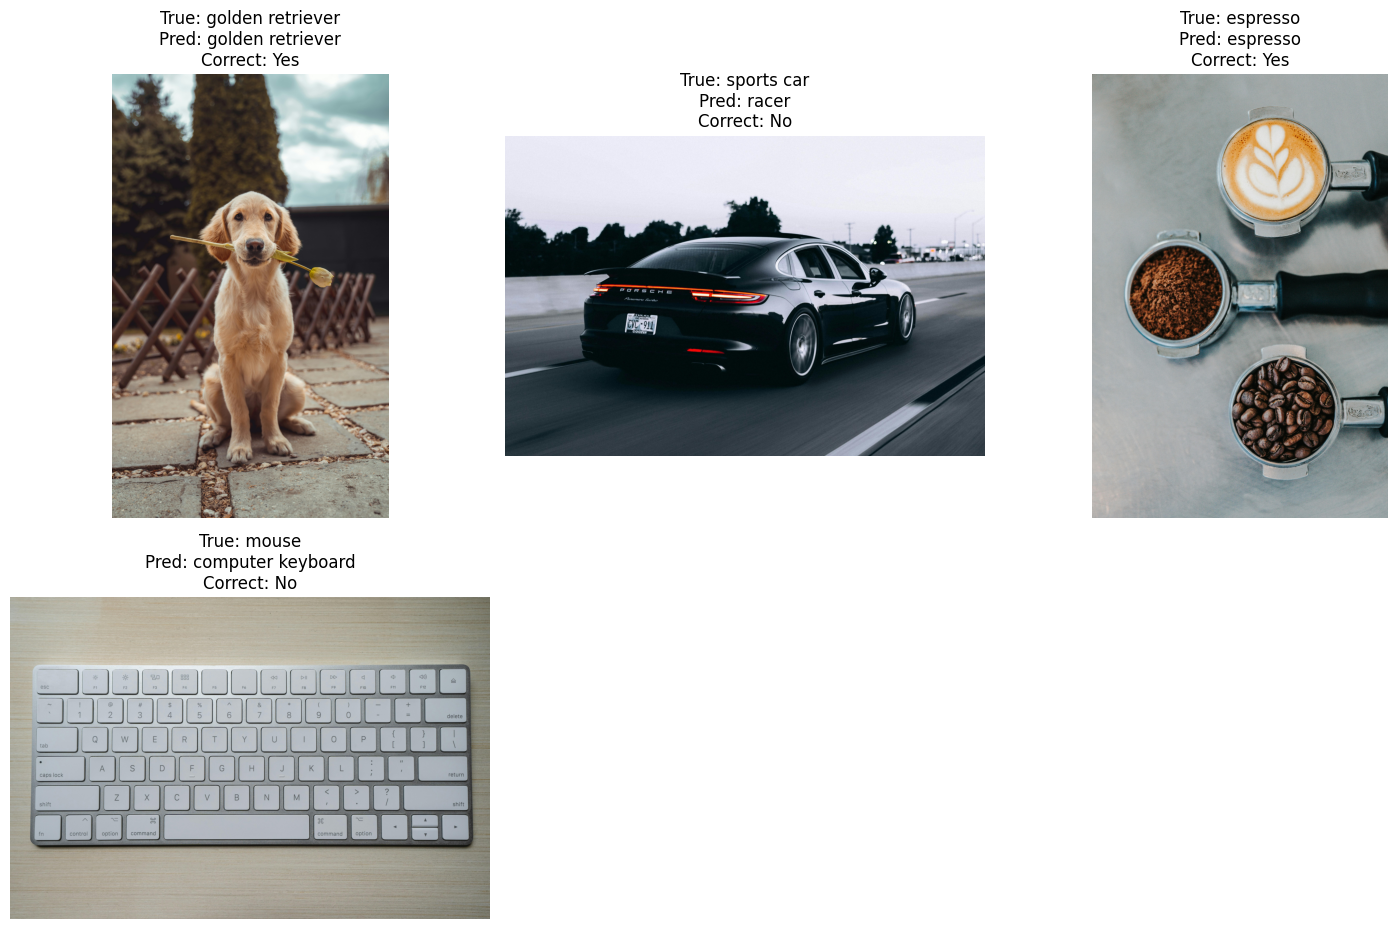

In [11]:
# Display images with predictions
plt.figure(figsize=(15, 10))

for i, path in enumerate(image_paths):
    img = Image.open(path).convert("RGB")

    true_label = results_df.iloc[i]["True Label"]
    pred_label = results_df.iloc[i]["Predicted Label"]
    correct = results_df.iloc[i]["Correct?"]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}\nCorrect: {correct}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Record Your Results


<div id="df-c4b11789-226e-4621-8ec1-d3178690bd8b" class="colab-df-container">
    <div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Image File</th>
      <th>True Label</th>
      <th>Predicted Label</th>
      <th>Correct?</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>golden_retriever.jpg</td>
      <td>golden retriever</td>
      <td>golden retriever</td>
      <td>Yes</td>
    </tr>
    <tr>
      <th>1</th>
      <td>sports_car.jpg</td>
      <td>sports car</td>
      <td>racer</td>
      <td>No</td>
    </tr>
    <tr>
      <th>2</th>
      <td>espresso.jpg</td>
      <td>espresso</td>
      <td>espresso</td>
      <td>Yes</td>
    </tr>
    <tr>
      <th>3</th>
      <td>computer_mouse.jpg</td>
      <td>mouse</td>
      <td>computer keyboard</td>
      <td>No</td>
    </tr>
  </tbody>
</table>
</div>
    <div class="colab-df-buttons">
      
  <div class="colab-df-container">
    <button class="colab-df-convert" onclick="convertToInteractive('df-c4b11789-226e-4621-8ec1-d3178690bd8b')"
            title="Convert this dataframe to an interactive table."
            style="display:none;">
      
  <svg xmlns="http://www.w3.org/2000/svg" height="24px" viewBox="0 -960 960 960">
    <path d="M120-120v-720h720v720H120Zm60-500h600v-160H180v160Zm220 220h160v-160H400v160Zm0 220h160v-160H400v160ZM180-400h160v-160H180v160Zm440 0h160v-160H620v160ZM180-180h160v-160H180v160Zm440 0h160v-160H620v160Z"/>
  </svg>
    </button>
    
  <style>
    .colab-df-container {
      display:flex;
      gap: 12px;
    }

    .colab-df-convert {
      background-color: #E8F0FE;
      border: none;
      border-radius: 50%;
      cursor: pointer;
      display: none;
      fill: #1967D2;
      height: 32px;
      padding: 0 0 0 0;
      width: 32px;
    }

    .colab-df-convert:hover {
      background-color: #E2EBFA;
      box-shadow: 0px 1px 2px rgba(60, 64, 67, 0.3), 0px 1px 3px 1px rgba(60, 64, 67, 0.15);
      fill: #174EA6;
    }

    .colab-df-buttons div {
      margin-bottom: 4px;
    }

    [theme=dark] .colab-df-convert {
      background-color: #3B4455;
      fill: #D2E3FC;
    }

    [theme=dark] .colab-df-convert:hover {
      background-color: #434B5C;
      box-shadow: 0px 1px 3px 1px rgba(0, 0, 0, 0.15);
      filter: drop-shadow(0px 1px 2px rgba(0, 0, 0, 0.3));
      fill: #FFFFFF;
    }
  </style>

  
  
    </div>
  </div>